Critical threshold p_c = 0.759
Critical fraction x_c = 0.545


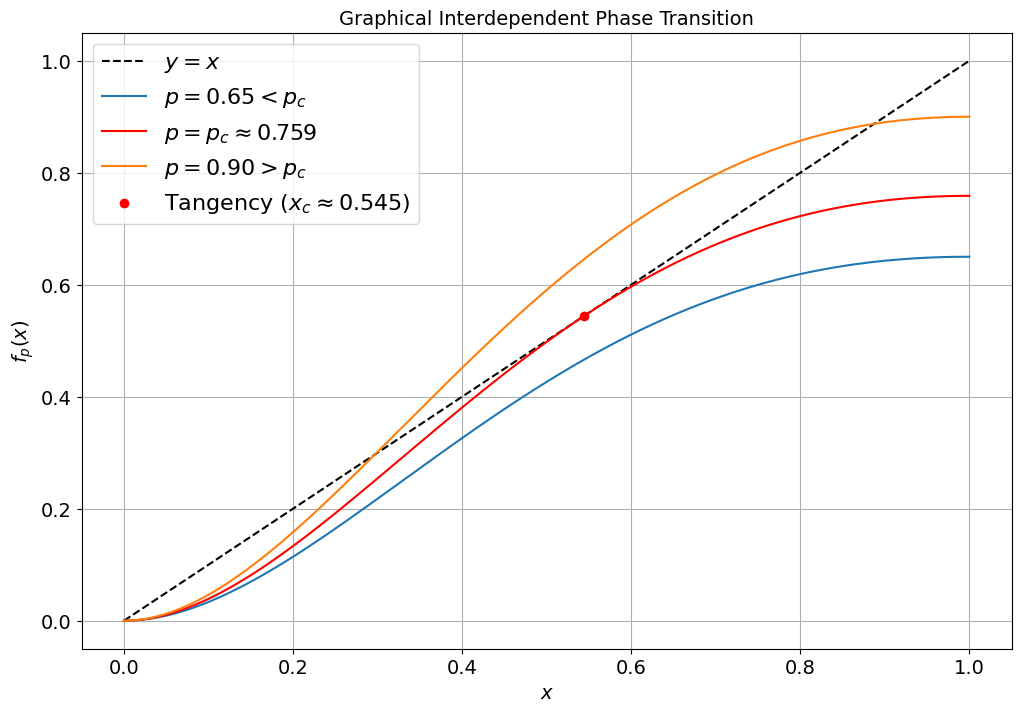

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# The condition f_p(x) = x becomes p * g(x) = x, where g(x) = [1 - (1-x)^2][1 - (1-x)^3]
# The tangency condition is f_p'(x) = 1 => p * g'(x) = 1
def equations(vars):
    x, p = vars
    g = (1 - (1 - x)**2) * (1 - (1 - x)**3)
    dg = 2 * (1 - x) * (1 - (1 - x)**3) + 3 * (1 - x)**2 * (1 - (1 - x)**2)
    return [p * g - x, p * dg - 1]

# Initial guesses for x_c and p_c
initial_guess = (0.5, 0.8)
x_c, p_c = fsolve(equations, initial_guess)

print(f"Critical threshold p_c = {p_c:.3f}")
print(f"Critical fraction x_c = {x_c:.3f}")

# Graphical argument implementation
x_vals = np.linspace(0, 1, 300)
def fp(x, p):
    return p * (1 - (1 - x)**2) * (1 - (1 - x)**3)

plt.figure(figsize=(12, 8))
plt.plot(x_vals, x_vals, 'k--', label='$y = x$')
plt.plot(x_vals, fp(x_vals, 0.65), label=f'$p = 0.65 < p_c$')
plt.plot(x_vals, fp(x_vals, p_c), label=f'$p = p_c \\approx {p_c:.3f}$', color='red')
plt.plot(x_vals, fp(x_vals, 0.90), label=f'$p = 0.90 > p_c$')

plt.scatter([x_c], [x_c], color='red', zorder=5, label=f'Tangency $(x_c \\approx {x_c:.3f})$')
plt.title('Graphical Interdependent Phase Transition',  fontsize=14)
plt.xlabel('$x$', fontsize=14)
plt.xticks(fontsize=14) 
plt.ylabel('$f_p(x)$', fontsize=14)
plt.yticks(fontsize=14) 
plt.legend(fontsize=16)
plt.grid(True)
plt.show()